# 14 - what the frozen features see: two test images, no training

**A100 GPU runtime**, standard RAM. The time of each step is printed, and the total at the end;
step 1 also prints the time per encoder and how much of it AnyUp took.
Nothing is trained and no result file is changed: the figures, one small CSV and one small array
file per image go to `sar-transfer/embeddings/` on Drive.

The heads of this study learn from the frozen encoder features. This notebook looks at those
features directly, with no probe and no decoder.
Same three encoders and layers as the study: C-RADIOv4-H layer 32,
satellite DINOv3 layer 21, photo DINOv3 layer 18 (the layer-sweep choice). Same preparation:
caffe normalisation, 512 px tiles, no overlap. Each image's tiles are put back together into one
map of 16 px patches, with the true zone of each patch (majority of its pixels: NA, stone,
glacier, ocean).

The images are the two test images of the README animations (the list is set in step 1):
- **hard**: Columbia, Sentinel-1, 2020-03-08 (`COL_2020-03-08_S1_20_3_094`)
- **easy**: Mapple, Sentinel-1, 2017-09-08 (`Mapple_2017-09-08_S1_20_2_009`)

| Step | What | Question |
|---|---|---|
| 1 | features (GPU), one encoder at a time, and their AnyUp versions | |
| 2 | embedding maps: PCA 1-3 as colours, k-means with 4 groups | do the features already separate the zones? |
| 3 | similarity search from the ocean patch next to the front, and from the glacier patch next to it | does the icy water in front of the glacier (melange) look like glacier to the encoder? |
| 4 | distance to the glacier and ocean centres: histograms and AUC | how well do plain distances tell ocean from glacier on this image? |
| 5 | steps 2-4 again on AnyUp features at 1/4 resolution (4 px blocks), whole image | do sharper, image-guided features separate the zones better? |
| 6 | zoom on the front: raw vs AnyUp 1/4 vs AnyUp at full resolution, in a 256 px window | what does full resolution add right at the front? |
| 7 | the numbers, saved as CSV | |
| 8 | the drawn maps saved as small arrays, for a GIF made later on the PC | |

Outputs in `sar-transfer/embeddings/`, per image `<stem>`:
- steps 2-4: `embedding_maps_<stem>.png`, `similarity_ocean_query_<stem>.png`,
  `similarity_glacier_query_<stem>.png`, `class_margins_<stem>.png`
- step 5: the same names with `_anyup`: `embedding_maps_anyup_<stem>.png`,
  `similarity_ocean_query_anyup_<stem>.png`, `similarity_glacier_query_anyup_<stem>.png`,
  `class_margins_anyup_<stem>.png`
- step 6: `zoom_front_<stem>.png` (colour maps) and `zoom_front_similarity_<stem>.png`
- step 7: `embeddings_numbers.csv` (all images in one table)
- step 8: `embeddings_gif_<stem>.npz`

**Descriptive only.** Two images, looked at after the test run. Nothing here is a test score,
and nothing here changes a choice in the study.

In [1]:
# --- cell: mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# <<<SARTRANSFER-SYNC-BEGIN>>>
# Empty sync cell: published notebooks carry no packed code. On your own machine,
# in the repository folder, run   python sync.py   and open the notebook again;
# this cell then holds the package source and unpacks it on the runtime.
raise RuntimeError("The sync cell is empty. On your own machine, in the repository folder, "
                   "run:  python sync.py  and reopen this notebook.")
# <<<SARTRANSFER-SYNC-END>>>

In [ ]:
# --- cell: secrets, GPU, RAM, data, AnyUp weights check ---
import os, shutil, time
from pathlib import Path
import psutil, torch
from sartransfer.env import load_env, require, model_cache_on_drive
from sartransfer.data import inventory as inv
from sartransfer.models.anyup_loader import load_anyup, fetch_anyup_weights

T0 = time.perf_counter()
load_env()
require("HF_TOKEN", "gated model weights")
model_cache_on_drive()          # weights downloaded once, kept on Drive
assert torch.cuda.is_available(), "switch to a GPU runtime"
g = torch.cuda.get_device_properties(0)
print(f"gpu: {g.name} | GPU memory {g.total_memory / 1e9:.0f} GB | system RAM {psutil.virtual_memory().total / 1e9:.0f} GB "
      f"| CPU cores {os.cpu_count()}")
DRIVE = Path("/content/drive/MyDrive")
RAW = DRIVE / "sar-transfer" / "raw"
ANYUP_W = DRIVE / "sar-transfer" / "weights" / "anyup_multi_backbone.pth"
inv.unzip_caffe(inv.fetch_caffe_zip(RAW), Path("/content/caffe"))
DATA = inv.find_data_root(Path("/content/caffe"))
df = inv.scan(DATA, subdirs=("sar_images",))
OUT = DRIVE / "sar-transfer" / "embeddings"      # figures and the CSV go straight to Drive
OUT.mkdir(parents=True, exist_ok=True)
anyup = load_anyup(fetch_anyup_weights(ANYUP_W))   # fetched once to Drive, hash-checked (as notebook 08)
print(len(df), "SAR images | AnyUp weights OK | free disk:", f"{shutil.disk_usage('/content').free/1e9:.0f} GB | output: {OUT}")

## Step 1: features of the chosen images

For each encoder: load it, run all chosen images through it exactly as in the study
(`features._prepare`, then `encode(tiles, layer=...)`), stitch each image's tile grids into one
patch map using the tile positions, then free the encoder before the next one. The zone label and
the validity of each patch come from the same preparation, so they line up with the features
patch for patch. Valid means inside the image; NA patches (radar shadow, outside the swath) are
kept and labelled NA.

The true front (from the `fronts` folder) is turned into patches too: a patch is a front patch if
it holds at least one front pixel. Step 3 needs it.

**AnyUp in the same pass.** The setup cell loads AnyUp (explained at step 5). While an encoder's
tiles are in memory, this step also makes the AnyUp versions of the same features: at 1/4
resolution for every tile (option A, step 5), and at full resolution for the one tile that holds
the ocean query of step 3 (option B, step 6). So each encoder is loaded only once. The printout
gives the time per encoder and how much of it AnyUp took, and per image the AnyUp grid and the
zoom window.

`IMAGES` below is the stem list; any CaFFe image stem works.

In [4]:
# --- cell: STEP 1 -- features, one encoder at a time (GPU), with their AnyUp versions ---
from sartransfer.embeddings import ENCODER_LAYERS, STEMS, extract

IMAGES = list(STEMS)            # CaFFe stems to look at; default: the two README GIF images (hard, easy)
t = time.perf_counter()
emb = extract(df, DATA, IMAGES, ENCODER_LAYERS, token=os.environ["HF_TOKEN"], anyup=anyup)
for stem, e in emb.items():
    cr, grid = e["crop"], next(iter(e["anyup_q"].values())).shape
    print(f"{stem}: image {e['shape'][0]} x {e['shape'][1]} px | patch map {e['labels'].shape[0]} x {e['labels'].shape[1]} "
          f"| {int(e['valid'].sum()):,} valid patches | {int(e['front'].sum())} front patches\n"
          f"  AnyUp 1/4: {grid[0]} x {grid[1]} blocks of 4 px | zoom window (step 6): y {cr['y0']}-{cr['y1'] - 1}, "
          f"x {cr['x0']}-{cr['x1'] - 1} ({cr['y1'] - cr['y0']} x {cr['x1'] - cr['x0']} px)")
print(f"step 1: {(time.perf_counter() - t) / 60:.1f} min | RAM used {psutil.virtual_memory().used / 1e9:.0f} GB")

installing ['open_clip_torch']


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

remote code verified: 26 files == reviewed copy (nvidia/C-RADIOv4-H@0057b339059c)


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

...

cradio-v4-h layer 32: 2 images, 1280-d, 1.8 min (of it AnyUp 1/4 + full-resolution window: 0.1 min)


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

dinov3-l-sat: 303.1 M parameters loaded
dinov3-l-sat layer 21: 2 images, 1024-d, 0.5 min (of it AnyUp 1/4 + full-resolution window: 0.0 min)


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

dinov3-l-photo: 303.1 M parameters loaded
dinov3-l-photo layer 18: 2 images, 1024-d, 0.3 min (of it AnyUp 1/4 + full-resolution window: 0.0 min)
COL_2020-03-08_S1_20_3_094: image 702 x 1492 px | patch map 44 x 94 | 4,136 valid patches | 81 front patches
  AnyUp 1/4: 176 x 373 blocks of 4 px | zoom window (step 6): y 256-511, x 616-871 (256 x 256 px)
Mapple_2017-09-08_S1_20_2_009: image 405 x 382 px | patch map 26 x 24 | 624 valid patches | 14 front patches
  AnyUp 1/4: 102 x 96 blocks of 4 px | zoom window (step 6): y 8-263, x 120-375 (256 x 256 px)
step 1: 2.7 min | RAM used 5 GB


## Step 2: embedding maps

Each patch's feature vector has 1,024 (DINOv3) or 1,280 (C-RADIO) numbers. PCA finds the three
directions in which this image's patches differ most; shown as red, green and blue they give a
rough map of what the encoder sees, with no training. PCA is fitted per image and per encoder on
its valid patches, and each colour is stretched from its 1st to its 99th percentile. Next to it,
k-means sorts the same patches into 4 groups (fixed seed).

The PCA colours and the cluster numbers mean nothing by themselves and cannot be compared between
rows. What counts is where the boundaries fall.

What to look for:
- Do colour or cluster boundaries follow the true zone boundaries, above all the glacier/ocean
  boundary (the calving front)?
- On Columbia: does the water right in front of the glacier get the glacier's colour or cluster,
  or the open ocean's?
- Do the three encoders draw the same boundaries?

Saved as `embedding_maps_<stem>.png`.

saved /content/drive/MyDrive/sar-transfer/embeddings/embedding_maps_COL_2020-03-08_S1_20_3_094.png


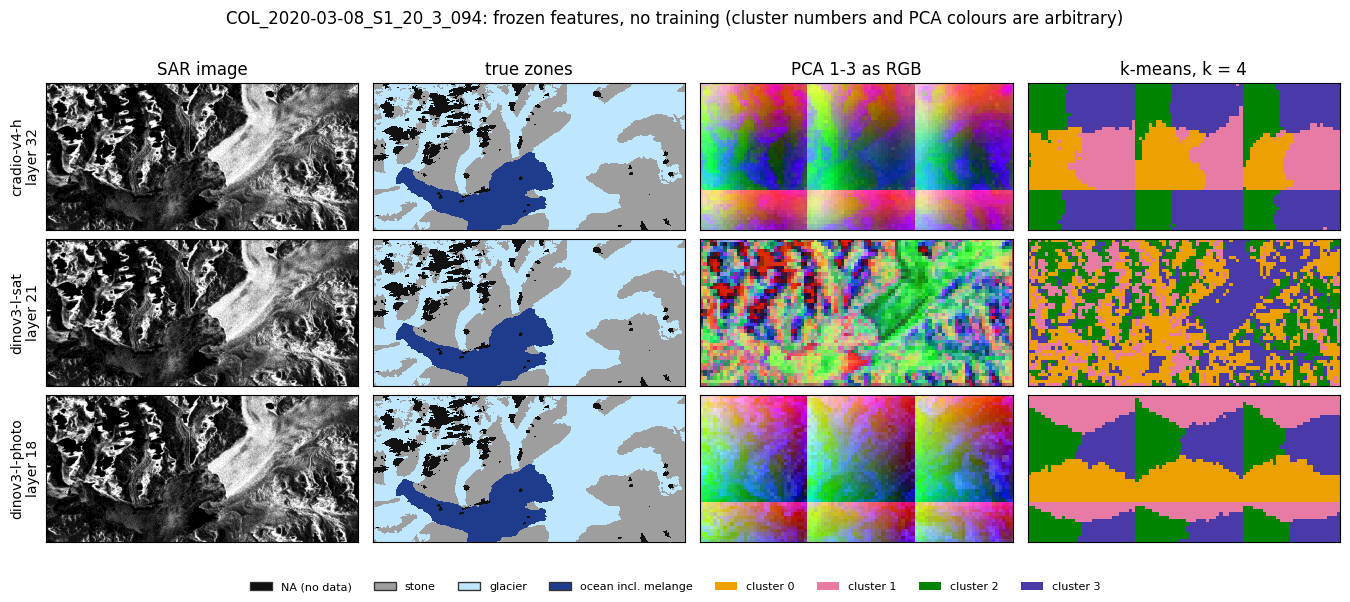

saved /content/drive/MyDrive/sar-transfer/embeddings/embedding_maps_Mapple_2017-09-08_S1_20_2_009.png


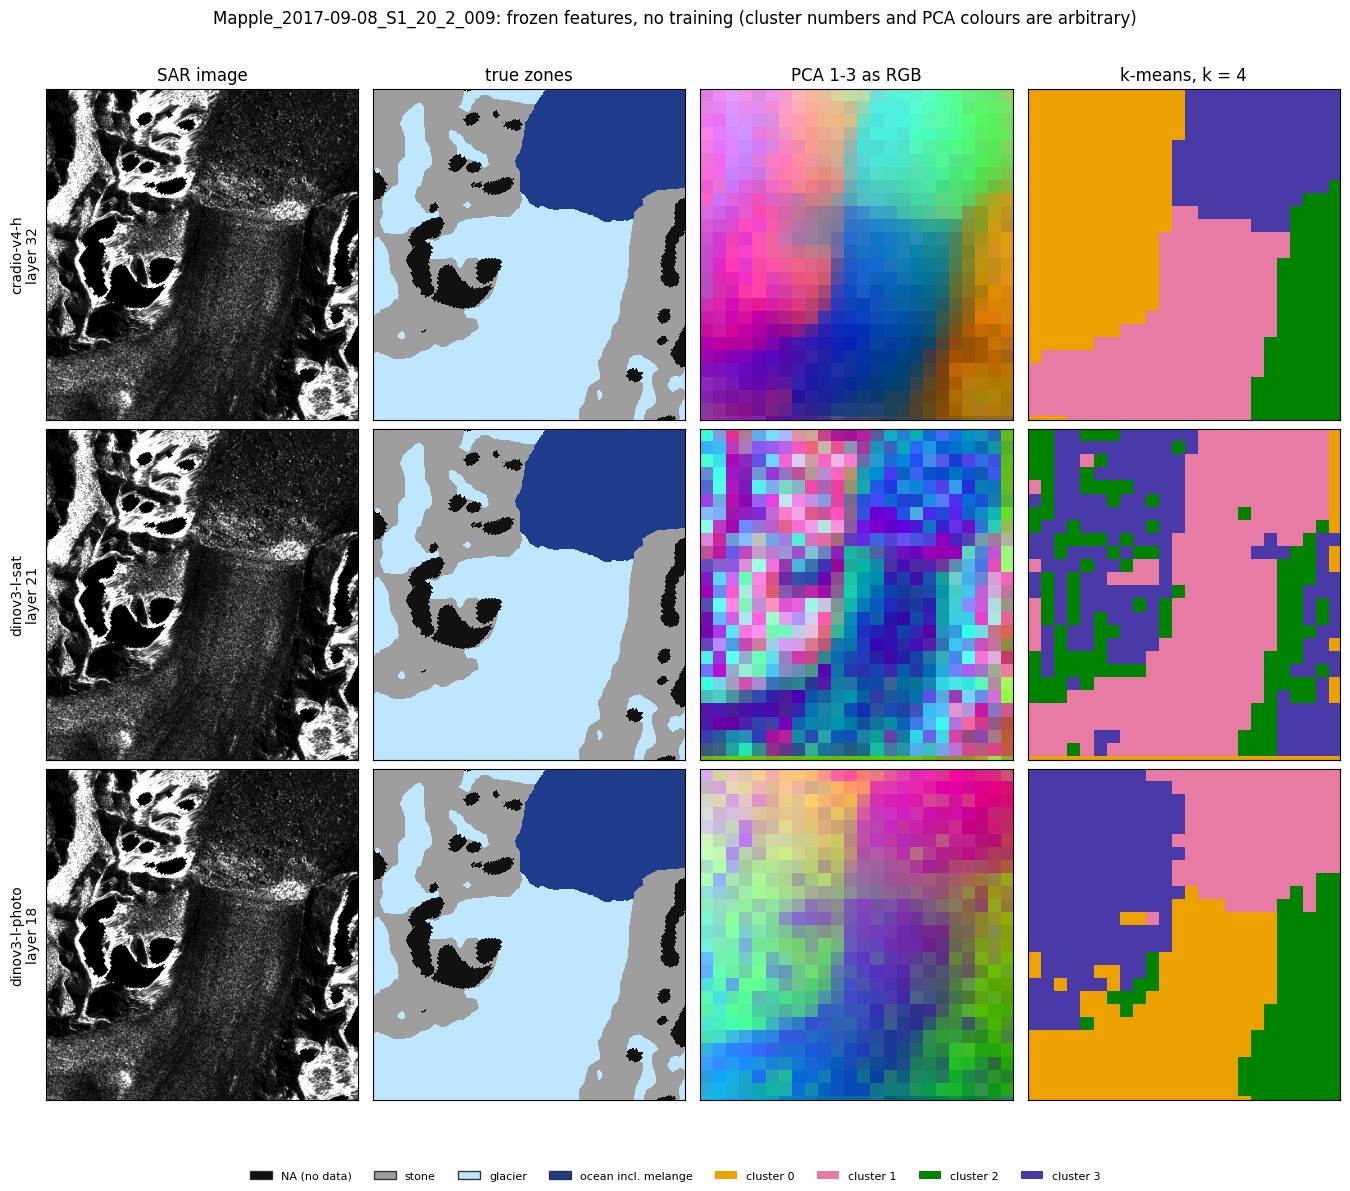

step 2: 0.2 min


In [5]:
# --- cell: STEP 2 -- embedding maps: PCA 1-3 as RGB and k-means (k = 4) ---
import matplotlib.pyplot as plt
from sartransfer.embeddings import plot_embedding_maps

t = time.perf_counter()
for stem, e in emb.items():
    plot_embedding_maps(e, OUT)
    plt.show()
print(f"step 2: {(time.perf_counter() - t) / 60:.1f} min")

## Step 3: similarity search from the ocean next to the front

The ocean class includes the ice melange: water full of broken ice in front of the glacier. The
suspected reason for the large front errors on Columbia's Sentinel-1 images (seen by eye in the
viewer, notebook 10) is that this melange looks like glacier. This step checks that directly on
the features.

**The query patch is chosen by a fixed rule, not by eye: the purest (>= 90 %) ocean patch closest
to the true front that does not itself contain the front; ties toward the middle of the front.**
In detail: among the valid patches labelled ocean that hold no front pixel and have at least 90 %
of their pixels in the ocean zone, the one with the shortest straight-line distance (in patches)
to the nearest patch that holds a front pixel. If several are equally close, the one closest to
the middle of the front (the median row and median column of the front patches), then the first
in reading order (row by row, left to right). Mixed patches at the front are skipped on purpose,
so the query is water in front of the glacier, not a blend of glacier and water. If no ocean
patch reaches 90 %, the purest one is used instead, and the printout and the CSV say so
(`query_fallback`). The cell prints where the query is, how far it is from the front, its pixel
shares and the rule.

For each encoder: the cosine similarity of that patch to every patch of the image (right panel,
darker = more similar), and the 100 most similar patches boxed in pink (the query itself not
counted). Printed: the share of each true class among the top 100, and among the top k20.

**Two sizes of the match list.** The top 100 is the same number on both images, but not the same
part of them: the images have different numbers of ocean and of glacier patches. That class size
(the number of valid patches of the query's class in the image) is printed under the query and
is in the CSV as `n_query_class`. 100 matches take a bigger part of a small class than of a
large one. The top **k20 = max(10, round(0.2 x n))**, n = that class size,
takes the same 20 % of the query's class on every image.
- **Between the two images, compare the k20 shares: they are like-for-like.**
- The top-100 shares compare the encoders on the same image (same image, same k).

As a contrast, the same with a **glacier** query, picked by the same rule: the purest (>= 90 %)
glacier patch closest to the true front that does not itself contain the front; ties toward the
middle of the front.

What to look for:
- **Ocean query, high glacier share:** the encoder sees the water in front of the glacier as
  glacier. That supports the melange explanation for this image.
- **Ocean query, high ocean share:** the encoder keeps it apart from glacier; on this image the
  features do not explain the error that way.
- Glacier query: the matches should be mostly glacier. Much ocean among them means the confusion
  goes both ways.
- Columbia (hard) against Mapple (easy) with the k20 shares, and the encoders against each other.
- A share is best read against how common each class is in the image: the patch counts are in
  the CSV of step 7. One query patch is a small sample: this is a picture, not a measurement.

Saved as `similarity_ocean_query_<stem>.png` and `similarity_glacier_query_<stem>.png`.

COL_2020-03-08_S1_20_3_094, ocean query: patch (row 31, col 46) = pixels (y 496, x 736), 1.0 patches from the true front | its pixels: glacier 0.00, ocean 0.99, stone 0.01, na 0.00
  rule: the purest (>= 90 %) ocean patch closest to the true front that does not itself contain the front; ties toward the middle of the front
  499 valid ocean patches in the image -> k20 = 100
  cradio-v4-h layer 32: top 100 = glacier 0.04, ocean 0.86, stone 0.10, na 0.00 | top 100 (k20) = glacier 0.04, ocean 0.86, stone 0.10, na 0.00
  dinov3-l-sat layer 21: top 100 = glacier 0.09, ocean 0.77, stone 0.14, na 0.00 | top 100 (k20) = glacier 0.09, ocean 0.77, stone 0.14, na 0.00
  dinov3-l-photo layer 18: top 100 = glacier 0.09, ocean 0.66, stone 0.25, na 0.00 | top 100 (k20) = glacier 0.09, ocean 0.66, stone 0.25, na 0.00
saved /content/drive/MyDrive/sar-transfer/embeddings/similarity_ocean_query_COL_2020-03-08_S1_20_3_094.png


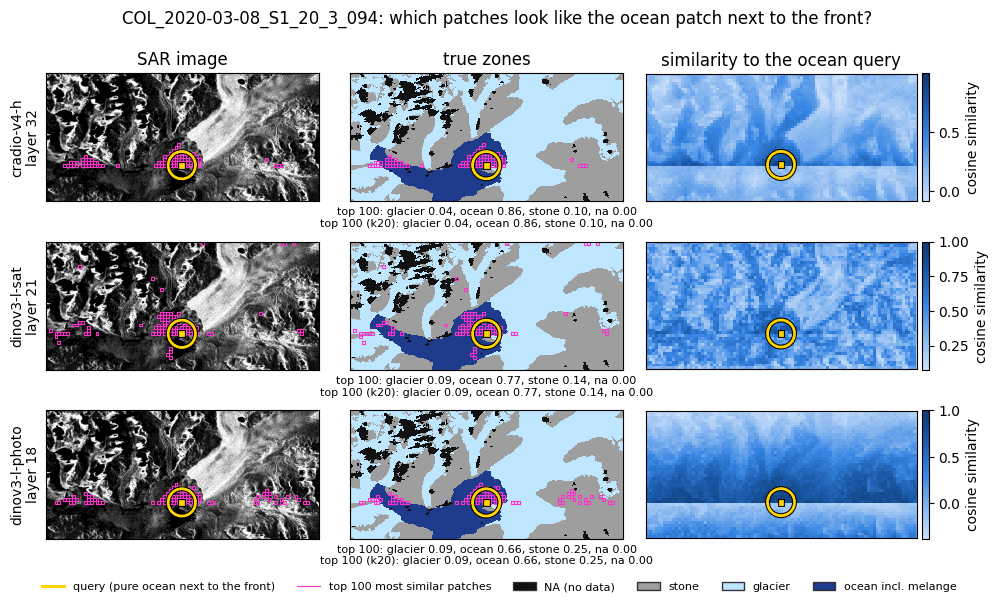

COL_2020-03-08_S1_20_3_094, glacier query: patch (row 32, col 52) = pixels (y 512, x 832), 1.0 patches from the true front | its pixels: glacier 1.00, ocean 0.00, stone 0.00, na 0.00
  rule: the purest (>= 90 %) glacier patch closest to the true front that does not itself contain the front; ties toward the middle of the front
  1,828 valid glacier patches in the image -> k20 = 366
  cradio-v4-h layer 32: top 100 = glacier 0.47, ocean 0.33, stone 0.20, na 0.00 | top 366 (k20) = glacier 0.50, ocean 0.24, stone 0.26, na 0.00
  dinov3-l-sat layer 21: top 100 = glacier 0.74, ocean 0.19, stone 0.07, na 0.00 | top 366 (k20) = glacier 0.65, ocean 0.21, stone 0.14, na 0.00
  dinov3-l-photo layer 18: top 100 = glacier 0.74, ocean 0.08, stone 0.17, na 0.01 | top 366 (k20) = glacier 0.66, ocean 0.09, stone 0.24, na 0.01
saved /content/drive/MyDrive/sar-transfer/embeddings/similarity_glacier_query_COL_2020-03-08_S1_20_3_094.png


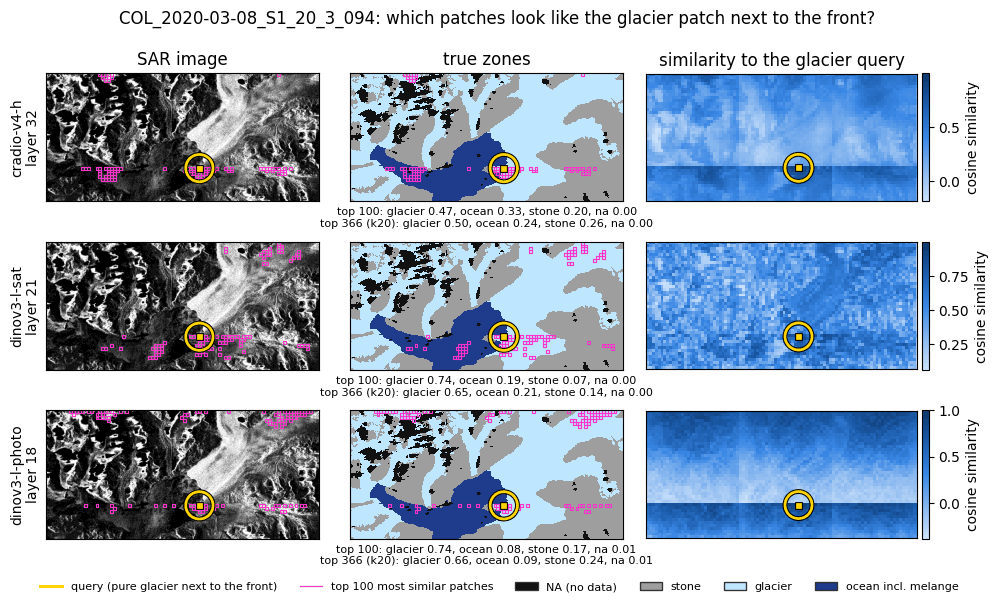

Mapple_2017-09-08_S1_20_2_009, ocean query: patch (row 8, col 15) = pixels (y 128, x 240), 1.0 patches from the true front | its pixels: glacier 0.00, ocean 1.00, stone 0.00, na 0.00
  rule: the purest (>= 90 %) ocean patch closest to the true front that does not itself contain the front; ties toward the middle of the front
  113 valid ocean patches in the image -> k20 = 23
  cradio-v4-h layer 32: top 100 = glacier 0.23, ocean 0.76, stone 0.01, na 0.00 | top 23 (k20) = glacier 0.04, ocean 0.96, stone 0.00, na 0.00
  dinov3-l-sat layer 21: top 100 = glacier 0.29, ocean 0.60, stone 0.11, na 0.00 | top 23 (k20) = glacier 0.04, ocean 0.96, stone 0.00, na 0.00
  dinov3-l-photo layer 18: top 100 = glacier 0.08, ocean 0.92, stone 0.00, na 0.00 | top 23 (k20) = glacier 0.00, ocean 1.00, stone 0.00, na 0.00
saved /content/drive/MyDrive/sar-transfer/embeddings/similarity_ocean_query_Mapple_2017-09-08_S1_20_2_009.png


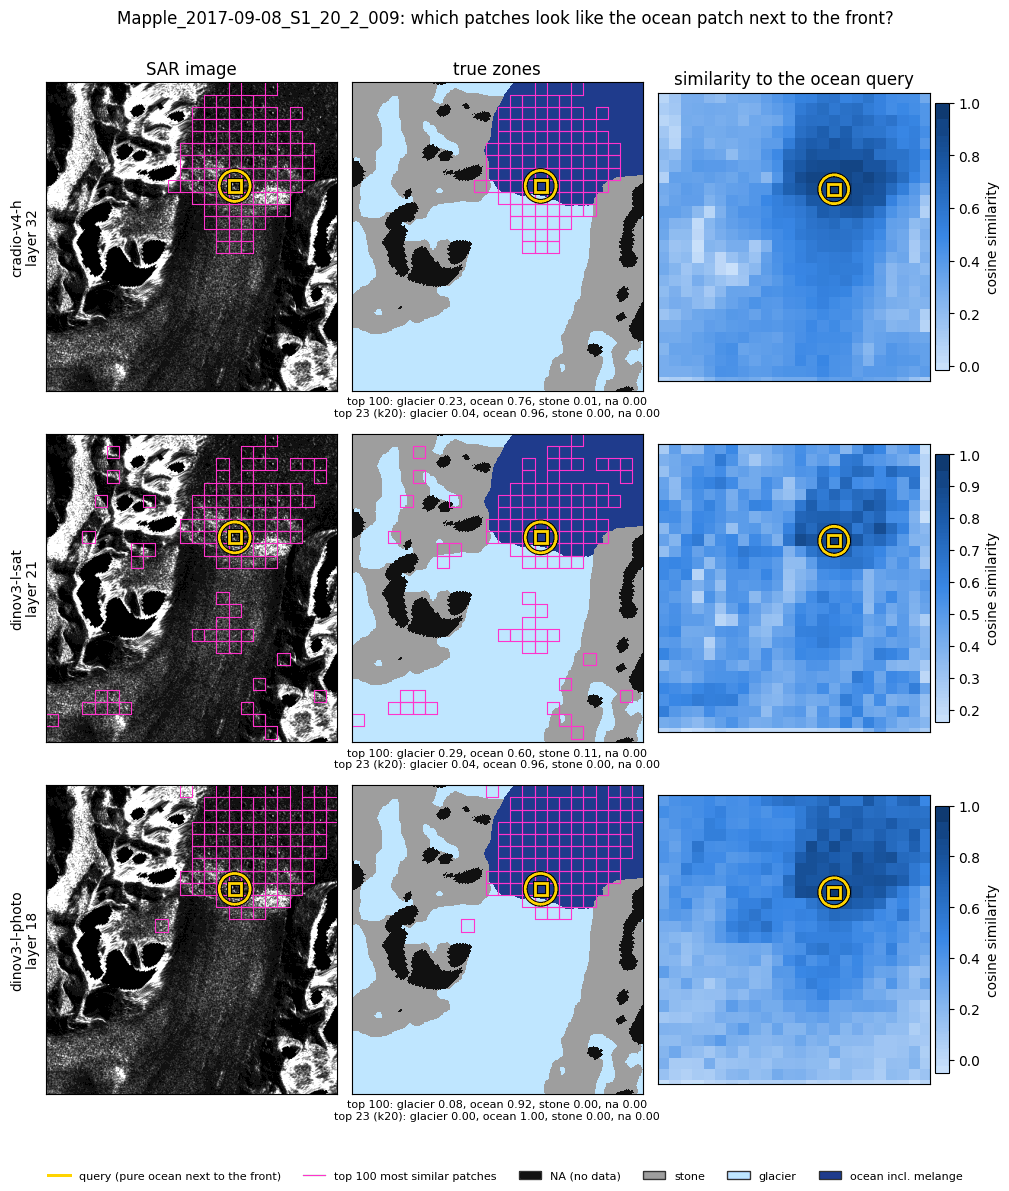

Mapple_2017-09-08_S1_20_2_009, glacier query: patch (row 10, col 15) = pixels (y 160, x 240), 1.0 patches from the true front | its pixels: glacier 1.00, ocean 0.00, stone 0.00, na 0.00
  rule: the purest (>= 90 %) glacier patch closest to the true front that does not itself contain the front; ties toward the middle of the front
  272 valid glacier patches in the image -> k20 = 54
  cradio-v4-h layer 32: top 100 = glacier 0.70, ocean 0.29, stone 0.01, na 0.00 | top 54 (k20) = glacier 0.83, ocean 0.17, stone 0.00, na 0.00
  dinov3-l-sat layer 21: top 100 = glacier 0.70, ocean 0.29, stone 0.01, na 0.00 | top 54 (k20) = glacier 0.76, ocean 0.24, stone 0.00, na 0.00
  dinov3-l-photo layer 18: top 100 = glacier 0.56, ocean 0.44, stone 0.00, na 0.00 | top 54 (k20) = glacier 0.76, ocean 0.24, stone 0.00, na 0.00
saved /content/drive/MyDrive/sar-transfer/embeddings/similarity_glacier_query_Mapple_2017-09-08_S1_20_2_009.png


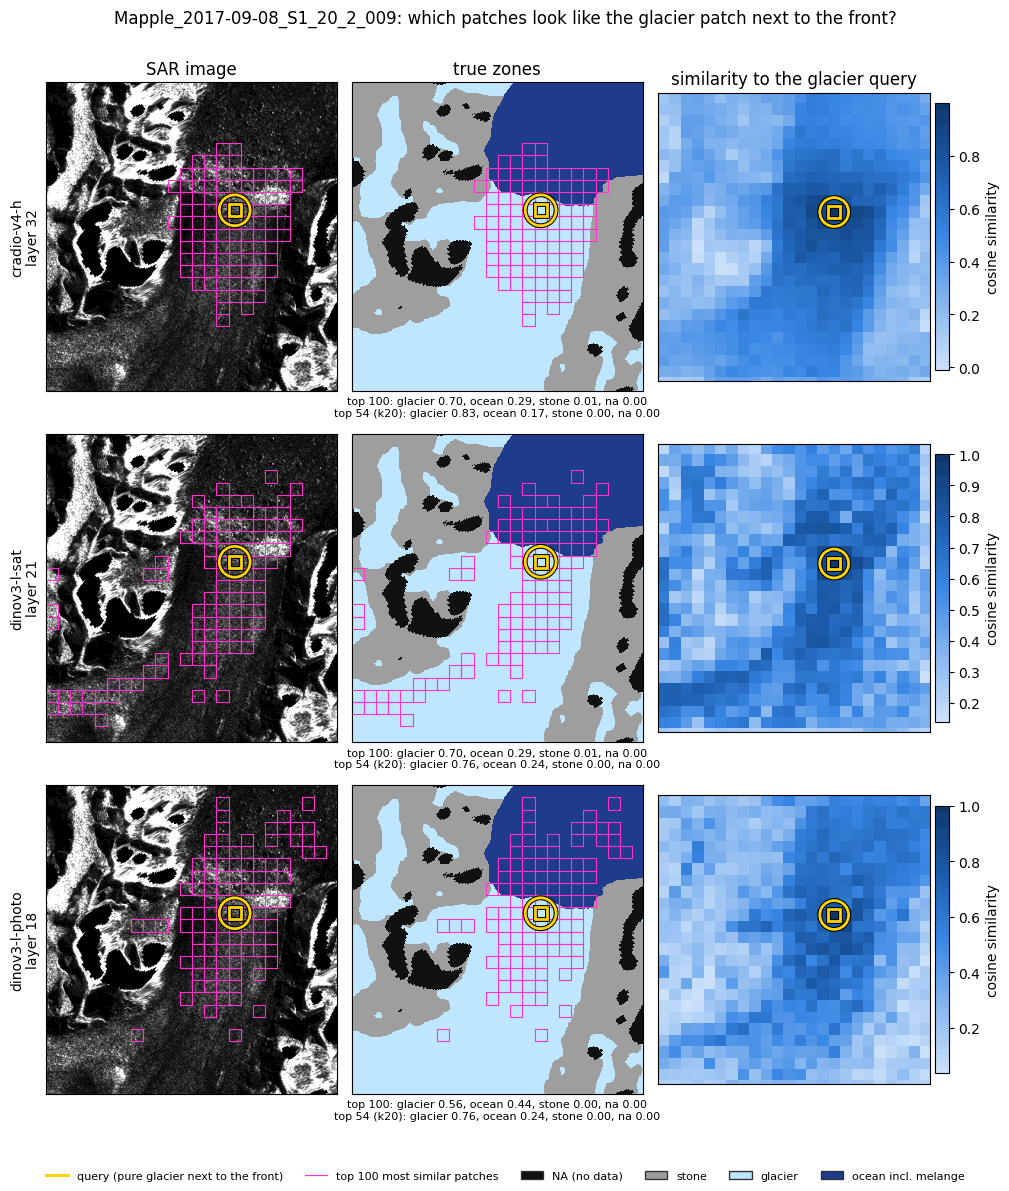

step 3: 0.2 min


In [6]:
# --- cell: STEP 3 -- similarity search: ocean query next to the front, glacier query as contrast ---
from sartransfer.embeddings import plot_similarity

t = time.perf_counter()
sim_records = []
for stem, e in emb.items():
    for query in ("ocean", "glacier"):
        _, recs = plot_similarity(e, query, OUT)
        sim_records += recs
        plt.show()
print(f"step 3: {(time.perf_counter() - t) / 60:.1f} min")

## Step 4: closer to the ocean or to the glacier?

The same question over all patches instead of one. For each encoder, the glacier centre is the
mean of all glacier patches of this image and the ocean centre the mean of all ocean patches
(each feature vector scaled to length 1 first). For every glacier and ocean patch:

`margin = cos(patch, ocean centre) - cos(patch, glacier centre)`

Above 0: the patch is closer to the ocean centre; below 0: closer to the glacier centre. The two
histograms show the glacier patches and the ocean patches.

The AUC is the chance that a random ocean patch has a larger margin than a random glacier patch
(ties count half): 1.0 = the margin separates the two classes completely, 0.5 = not at all. It uses
ranks only; nothing is trained and no threshold is chosen. The centres come from this image's own
true labels, so the AUC says how well distance CAN tell the two apart on this image: a
description, not a prediction.

What to look for:
- Ocean patches on the glacier side of 0 (part of the ocean histogram left of 0): ocean that looks
  like glacier, e.g. melange.
- A lower AUC on Columbia than on Mapple fits the melange explanation; similar AUCs do not.
- Which encoder separates the two classes best on each image.

Saved as `class_margins_<stem>.png`.

COL_2020-03-08_S1_20_3_094  cradio-v4-h layer 32: AUC ocean vs glacier 0.935 (499 ocean, 1,828 glacier patches)
COL_2020-03-08_S1_20_3_094  dinov3-l-sat layer 21: AUC ocean vs glacier 0.872 (499 ocean, 1,828 glacier patches)
COL_2020-03-08_S1_20_3_094  dinov3-l-photo layer 18: AUC ocean vs glacier 0.737 (499 ocean, 1,828 glacier patches)
saved /content/drive/MyDrive/sar-transfer/embeddings/class_margins_COL_2020-03-08_S1_20_3_094.png


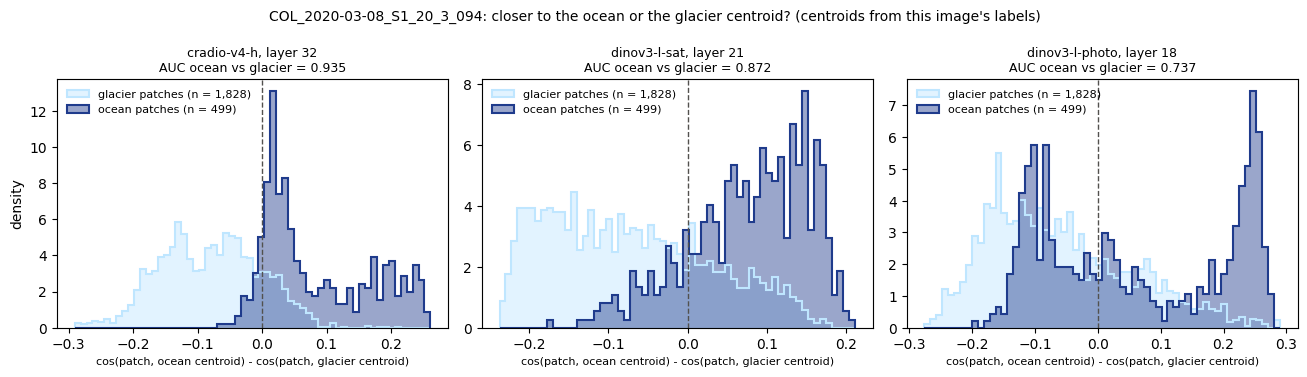

Mapple_2017-09-08_S1_20_2_009  cradio-v4-h layer 32: AUC ocean vs glacier 0.999 (113 ocean, 272 glacier patches)
Mapple_2017-09-08_S1_20_2_009  dinov3-l-sat layer 21: AUC ocean vs glacier 0.990 (113 ocean, 272 glacier patches)
Mapple_2017-09-08_S1_20_2_009  dinov3-l-photo layer 18: AUC ocean vs glacier 0.975 (113 ocean, 272 glacier patches)
saved /content/drive/MyDrive/sar-transfer/embeddings/class_margins_Mapple_2017-09-08_S1_20_2_009.png


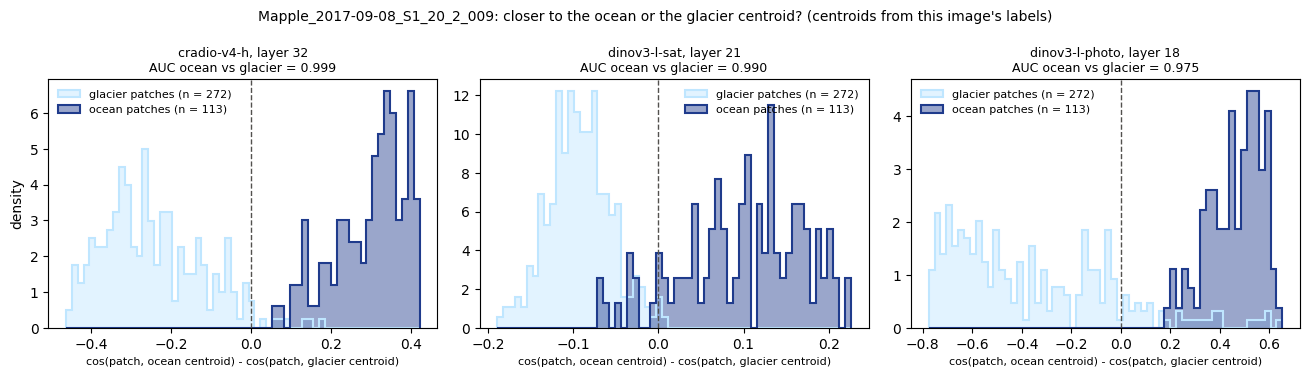

step 4: 0.0 min


In [7]:
# --- cell: STEP 4 -- class margins: histograms and AUC ---
from sartransfer.embeddings import plot_margins

t = time.perf_counter()
margin_records = []
for stem, e in emb.items():
    _, recs = plot_margins(e, OUT)
    margin_records += recs
    plt.show()
print(f"step 4: {(time.perf_counter() - t) / 60:.1f} min")

## Step 5: AnyUp features over the whole image (option A)

**What AnyUp is.** The encoders give one feature vector per 16 x 16 px patch. AnyUp is a small
upsampler, trained by its authors and frozen (nothing is trained here). It turns the patch
features into features on a finer grid, guided by the SAR image: each new feature is a weighted
mix of nearby patch features, and the image decides the weights. So edges in the image can make
the features sharper. The study used it in heads 2, 4 and 6. It helped the linear probe (head 2);
with the learned decoders (heads 4 and 6) it brought no clear gain over the plain decoder
(head 3). AnyUp was trained on photos, not on SAR.

**Option A (this step):** AnyUp at 1/4 resolution over the whole image, exactly as head 6 used
it: per 512 px tile the guide image is shrunk to 128 x 128 and the output is 128 x 128, so one
feature per 4 x 4 px block (16 blocks per patch), in the same bf16 precision as the reported
runs. The zone of a block is the majority of its pixels. Steps 2-4 are repeated on the blocks:
- **Maps:** PCA 1-3 as colours and k-means with 4 groups. k-means is fitted on at most 20,000
  blocks (fixed seed), then every block gets its nearest group.
- **Similarity:** the query spot is the same as for the raw features: the same 16 px patch,
  picked by the rule of step 3. Its vector is the mean of its 16 blocks (each scaled to length
  1), and those 16 blocks are left out of the list. The lists cover the same area as in step 3:
  the top 1,600 blocks = 100 patches, and 16 x k20 blocks = k20 patches (k20 from the patch count
  of step 3). The shares count blocks. The best blocks are outlined in pink.
- **Margins and AUC:** as in step 4, over blocks.

Everything here is descriptive, like steps 2-4.

What to look for:
- Sharper boundaries along the front than in the raw maps of step 2.
- Whether the icy fjord (melange) separates from the glacier better: compare the ocean query's
  glacier share (raw top 100 vs AnyUp top 1,600 blocks; raw k20 vs AnyUp 16 x k20) and the AUC,
  raw vs AnyUp, per encoder and image. They are side by side in the CSV of step 7 (column
  `features`).
- Whether the three encoders still differ in the same way.

Saved as `embedding_maps_anyup_<stem>.png`, `similarity_ocean_query_anyup_<stem>.png`,
`similarity_glacier_query_anyup_<stem>.png` and `class_margins_anyup_<stem>.png`.

saved /content/drive/MyDrive/sar-transfer/embeddings/embedding_maps_anyup_COL_2020-03-08_S1_20_3_094.png


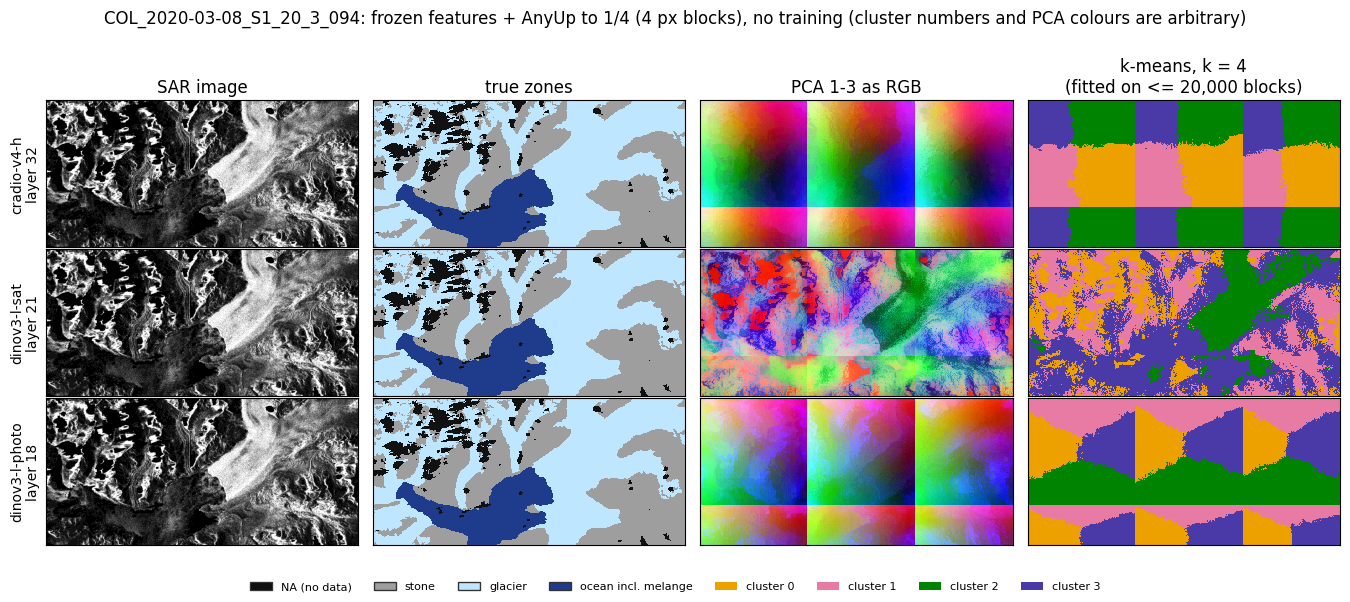

COL_2020-03-08_S1_20_3_094, ocean query, AnyUp 1/4: the same patch (row 31, col 46) = its 16 blocks | top 1,600 blocks = the area of 100 patches | 16 x k20 = 1,600 blocks (499 valid ocean patches -> k20 = 100)
  cradio-v4-h layer 32: top 1,600 blocks = glacier 0.01, ocean 0.94, stone 0.04, na 0.01 | top 1,600 blocks (16 x k20) = glacier 0.01, ocean 0.94, stone 0.04, na 0.01
  dinov3-l-sat layer 21: top 1,600 blocks = glacier 0.01, ocean 0.94, stone 0.04, na 0.01 | top 1,600 blocks (16 x k20) = glacier 0.01, ocean 0.94, stone 0.04, na 0.01
  dinov3-l-photo layer 18: top 1,600 blocks = glacier 0.04, ocean 0.78, stone 0.17, na 0.01 | top 1,600 blocks (16 x k20) = glacier 0.04, ocean 0.78, stone 0.17, na 0.01
saved /content/drive/MyDrive/sar-transfer/embeddings/similarity_ocean_query_anyup_COL_2020-03-08_S1_20_3_094.png


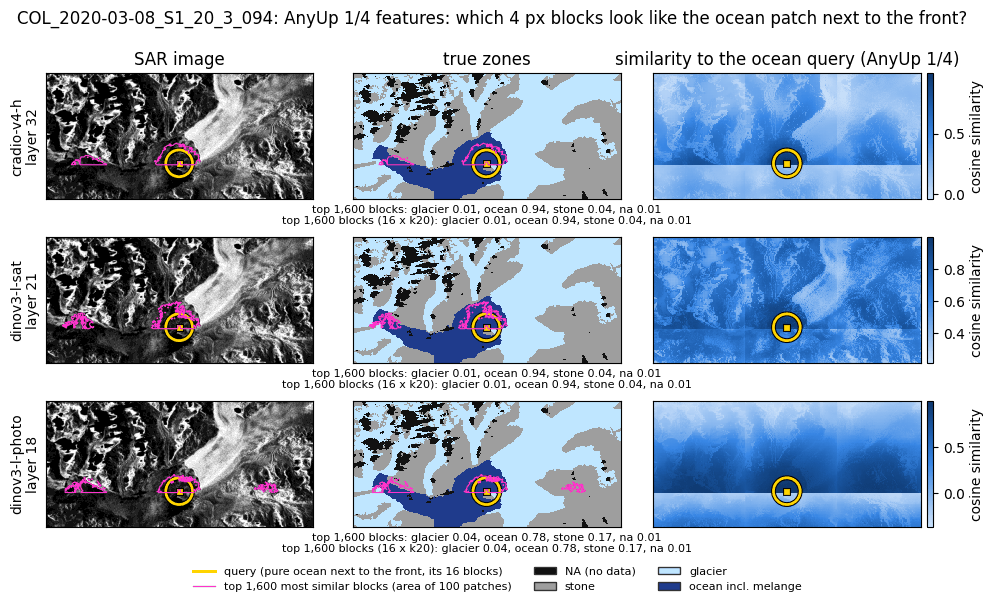

COL_2020-03-08_S1_20_3_094, glacier query, AnyUp 1/4: the same patch (row 32, col 52) = its 16 blocks | top 1,600 blocks = the area of 100 patches | 16 x k20 = 5,856 blocks (1,828 valid glacier patches -> k20 = 366)
  cradio-v4-h layer 32: top 1,600 blocks = glacier 0.41, ocean 0.45, stone 0.12, na 0.01 | top 5,856 blocks (16 x k20) = glacier 0.43, ocean 0.26, stone 0.30, na 0.01
  dinov3-l-sat layer 21: top 1,600 blocks = glacier 0.84, ocean 0.11, stone 0.05, na 0.00 | top 5,856 blocks (16 x k20) = glacier 0.64, ocean 0.21, stone 0.15, na 0.00
  dinov3-l-photo layer 18: top 1,600 blocks = glacier 0.63, ocean 0.14, stone 0.23, na 0.00 | top 5,856 blocks (16 x k20) = glacier 0.55, ocean 0.15, stone 0.28, na 0.01
saved /content/drive/MyDrive/sar-transfer/embeddings/similarity_glacier_query_anyup_COL_2020-03-08_S1_20_3_094.png


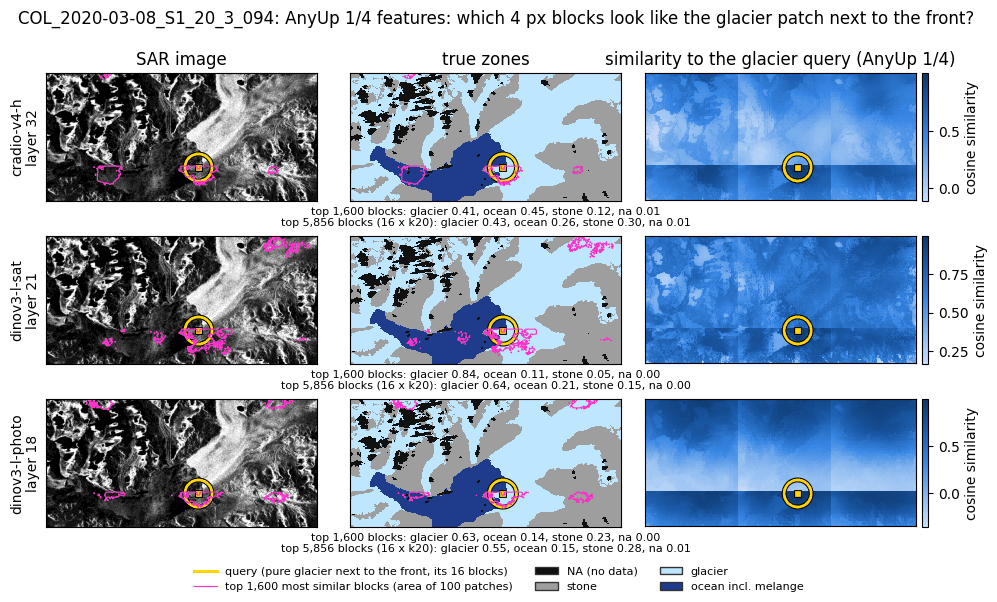

COL_2020-03-08_S1_20_3_094, AnyUp 1/4  cradio-v4-h layer 32: AUC ocean vs glacier 0.947 (7,785 ocean, 28,713 glacier blocks)
COL_2020-03-08_S1_20_3_094, AnyUp 1/4  dinov3-l-sat layer 21: AUC ocean vs glacier 0.922 (7,785 ocean, 28,713 glacier blocks)
COL_2020-03-08_S1_20_3_094, AnyUp 1/4  dinov3-l-photo layer 18: AUC ocean vs glacier 0.738 (7,785 ocean, 28,713 glacier blocks)
saved /content/drive/MyDrive/sar-transfer/embeddings/class_margins_anyup_COL_2020-03-08_S1_20_3_094.png


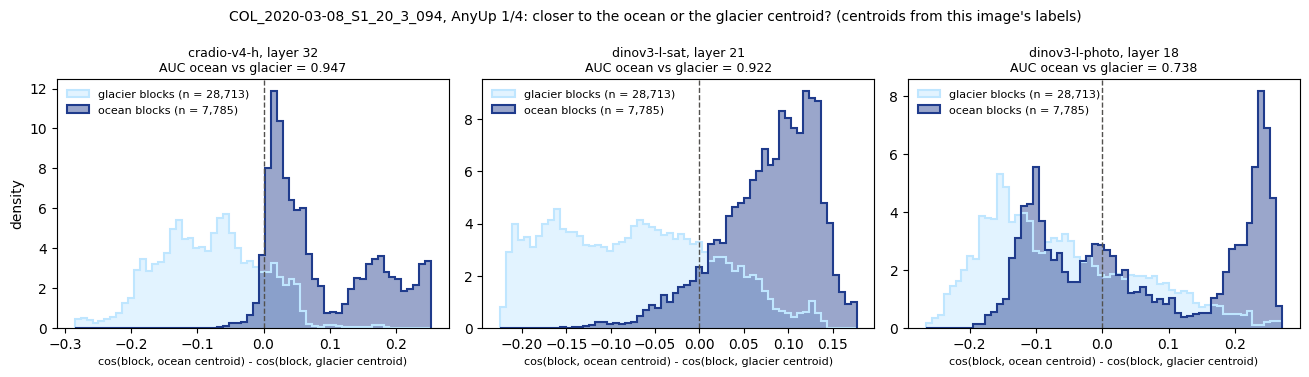

saved /content/drive/MyDrive/sar-transfer/embeddings/embedding_maps_anyup_Mapple_2017-09-08_S1_20_2_009.png


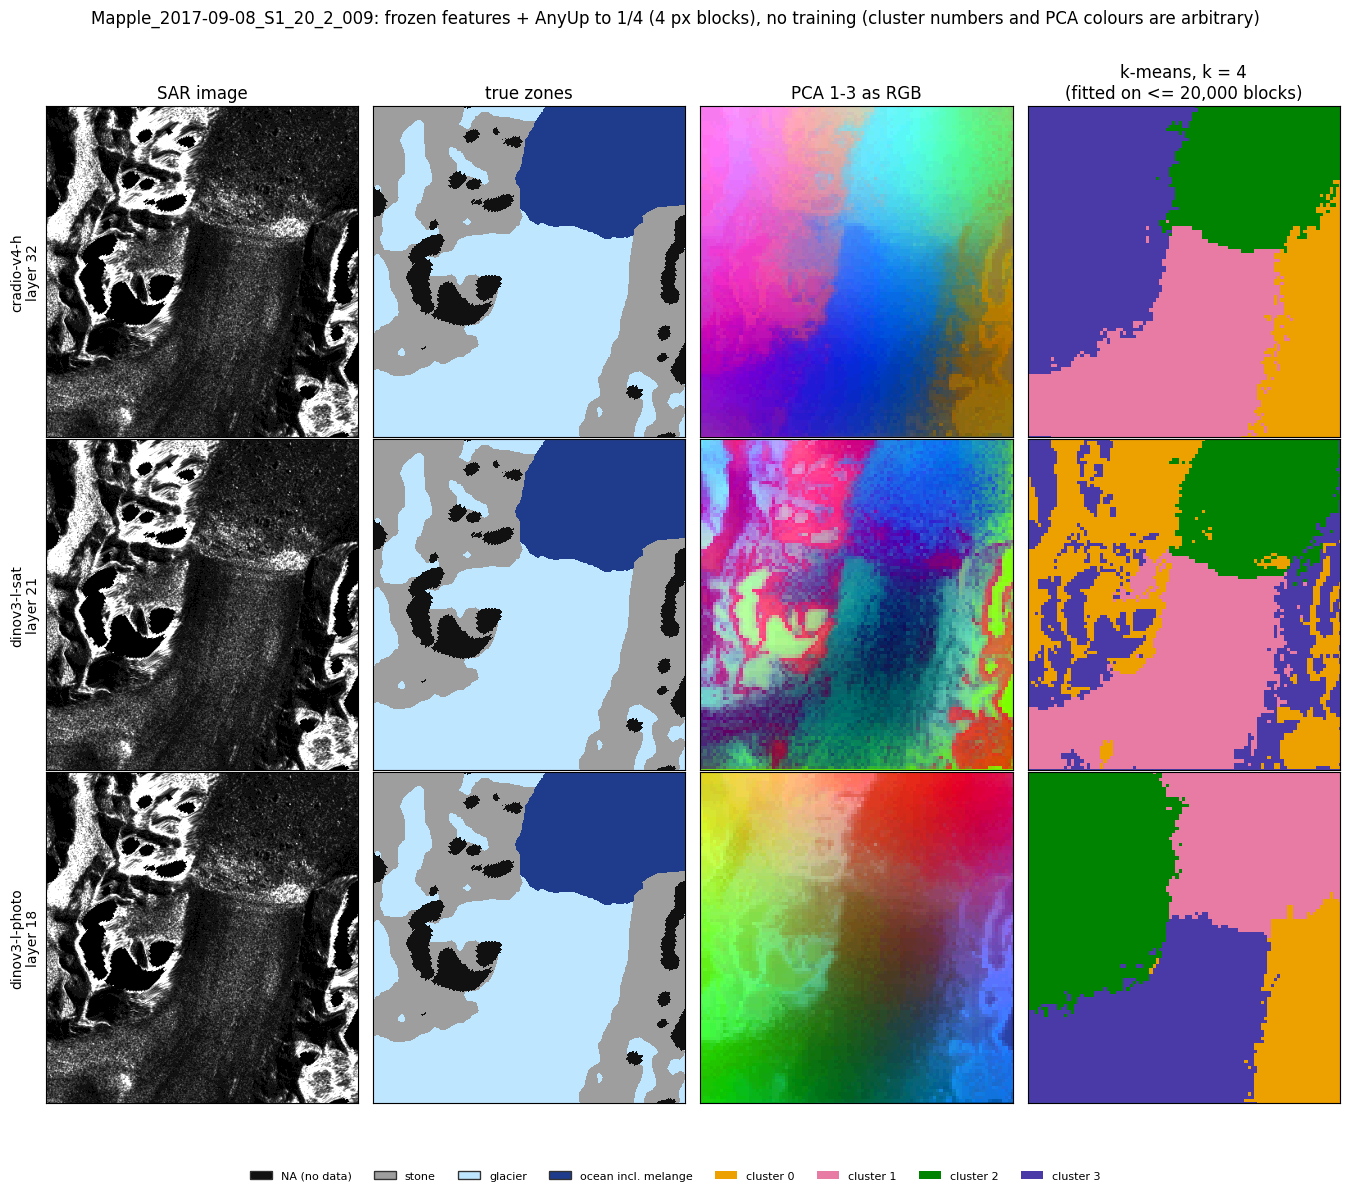

Mapple_2017-09-08_S1_20_2_009, ocean query, AnyUp 1/4: the same patch (row 8, col 15) = its 16 blocks | top 1,600 blocks = the area of 100 patches | 16 x k20 = 368 blocks (113 valid ocean patches -> k20 = 23)
  cradio-v4-h layer 32: top 1,600 blocks = glacier 0.27, ocean 0.67, stone 0.05, na 0.00 | top 368 blocks (16 x k20) = glacier 0.21, ocean 0.79, stone 0.00, na 0.00
  dinov3-l-sat layer 21: top 1,600 blocks = glacier 0.34, ocean 0.62, stone 0.04, na 0.00 | top 368 blocks (16 x k20) = glacier 0.20, ocean 0.80, stone 0.00, na 0.00
  dinov3-l-photo layer 18: top 1,600 blocks = glacier 0.14, ocean 0.81, stone 0.04, na 0.00 | top 368 blocks (16 x k20) = glacier 0.15, ocean 0.85, stone 0.00, na 0.00
saved /content/drive/MyDrive/sar-transfer/embeddings/similarity_ocean_query_anyup_Mapple_2017-09-08_S1_20_2_009.png


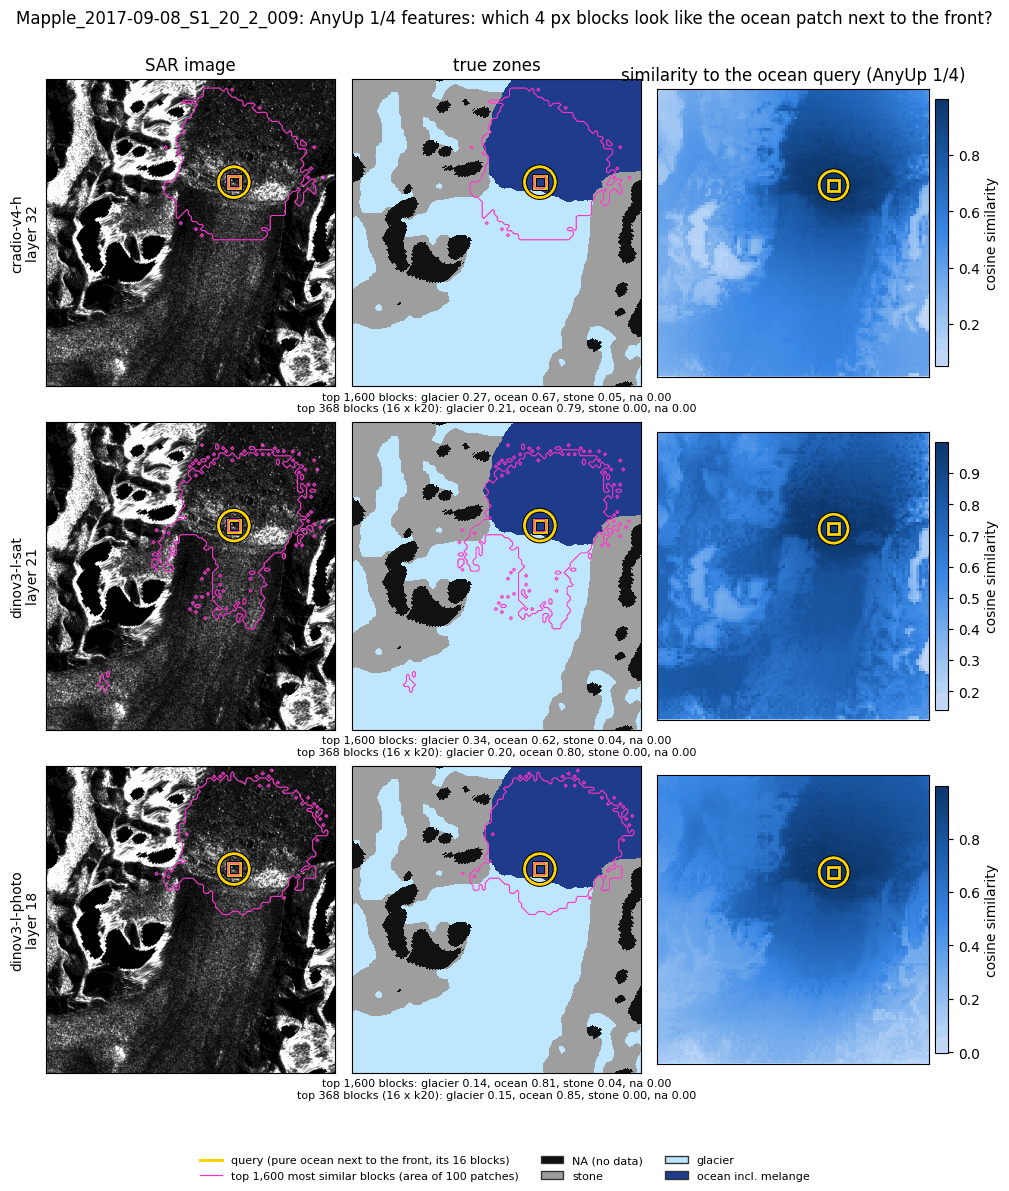

Mapple_2017-09-08_S1_20_2_009, glacier query, AnyUp 1/4: the same patch (row 10, col 15) = its 16 blocks | top 1,600 blocks = the area of 100 patches | 16 x k20 = 864 blocks (272 valid glacier patches -> k20 = 54)
  cradio-v4-h layer 32: top 1,600 blocks = glacier 0.58, ocean 0.38, stone 0.04, na 0.00 | top 864 blocks (16 x k20) = glacier 0.63, ocean 0.36, stone 0.01, na 0.00
  dinov3-l-sat layer 21: top 1,600 blocks = glacier 0.58, ocean 0.40, stone 0.02, na 0.00 | top 864 blocks (16 x k20) = glacier 0.57, ocean 0.42, stone 0.01, na 0.00
  dinov3-l-photo layer 18: top 1,600 blocks = glacier 0.54, ocean 0.43, stone 0.03, na 0.00 | top 864 blocks (16 x k20) = glacier 0.65, ocean 0.34, stone 0.01, na 0.00
saved /content/drive/MyDrive/sar-transfer/embeddings/similarity_glacier_query_anyup_Mapple_2017-09-08_S1_20_2_009.png


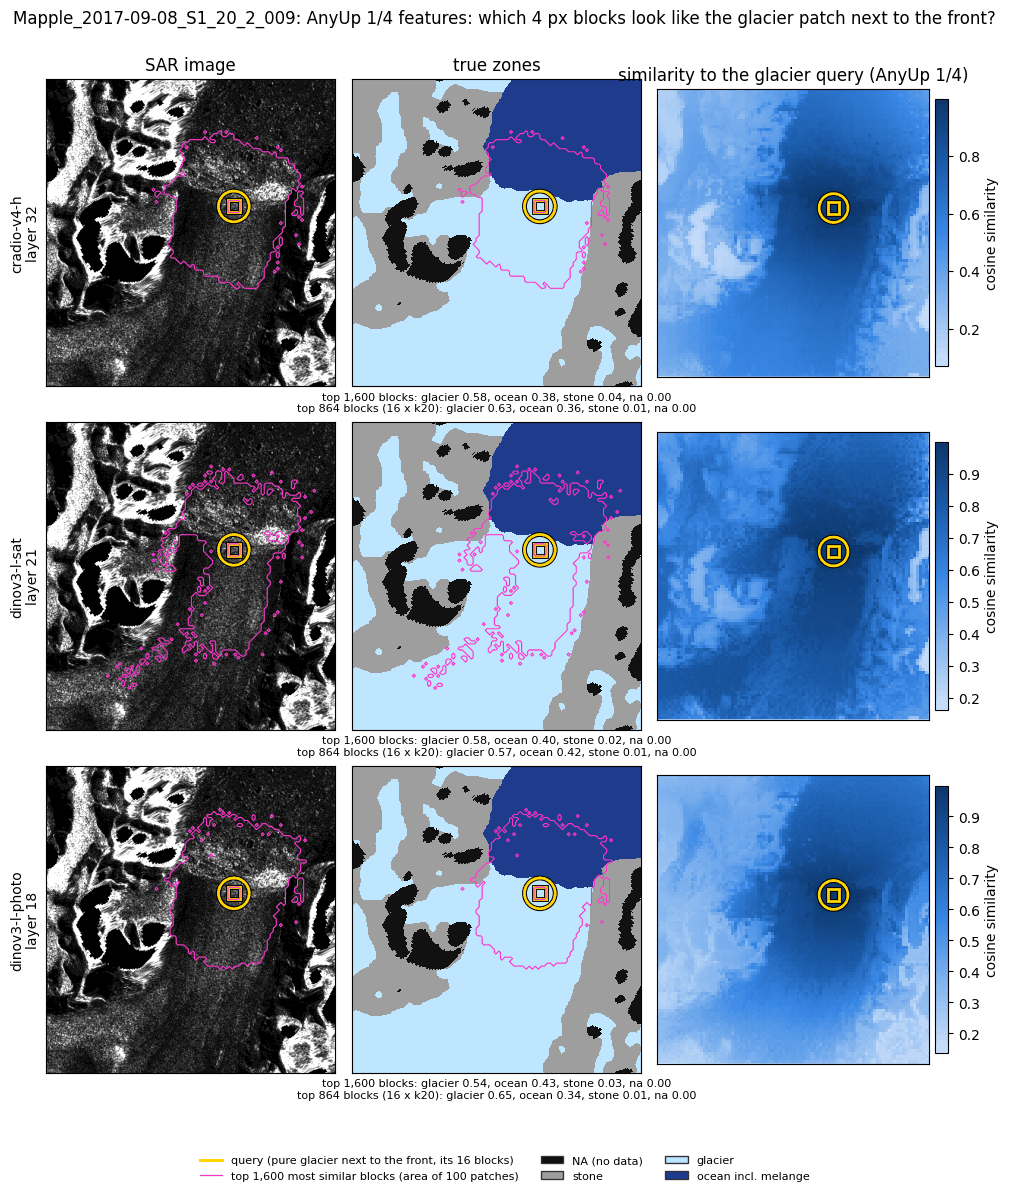

Mapple_2017-09-08_S1_20_2_009, AnyUp 1/4  cradio-v4-h layer 32: AUC ocean vs glacier 0.999 (1,784 ocean, 4,159 glacier blocks)
Mapple_2017-09-08_S1_20_2_009, AnyUp 1/4  dinov3-l-sat layer 21: AUC ocean vs glacier 0.999 (1,784 ocean, 4,159 glacier blocks)
Mapple_2017-09-08_S1_20_2_009, AnyUp 1/4  dinov3-l-photo layer 18: AUC ocean vs glacier 0.977 (1,784 ocean, 4,159 glacier blocks)
saved /content/drive/MyDrive/sar-transfer/embeddings/class_margins_anyup_Mapple_2017-09-08_S1_20_2_009.png


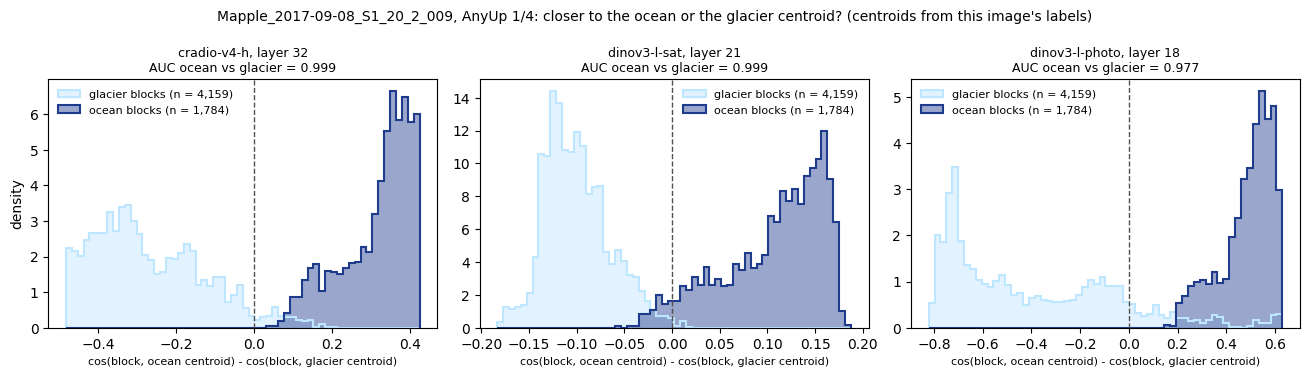

step 5: 0.6 min


In [8]:
# --- cell: STEP 5 -- AnyUp 1/4 over the whole image (option A): maps, similarity, margins ---
from sartransfer.embeddings import plot_embedding_maps, plot_margins, plot_similarity_anyup

t = time.perf_counter()
anyup_sim_records, anyup_margin_records = [], []
for stem, e in emb.items():
    plot_embedding_maps(e, OUT, features="anyup_quarter")
    plt.show()
    for query in ("ocean", "glacier"):
        _, recs = plot_similarity_anyup(e, query, OUT)
        anyup_sim_records += recs
        plt.show()
    _, recs = plot_margins(e, OUT, features="anyup_quarter")
    anyup_margin_records += recs
    plt.show()
print(f"step 5: {(time.perf_counter() - t) / 60:.1f} min")

## Step 6: zoom on the front, AnyUp at full resolution (option B)

Full resolution for a whole image is heavy, so option B looks at one window: 256 x 256 px,
centred on the ocean query patch of step 3 (the same spot), inside the 512 px tile that holds
that patch. At a tile or image edge the window moves inward; if the tile holds less than 256 px
of the image, the window is cut to what it holds (step 1 prints the window). AnyUp runs on that
tile at full resolution (one feature per pixel), as heads 2 and 4 used it.

In the window, three versions of each encoder's features, pixel by pixel:
- **raw patches**: each pixel takes the vector of its 16 px patch;
- **AnyUp 1/4**: each pixel takes the vector of its 4 px block (step 5);
- **AnyUp full**: each pixel has its own vector.

For each version: PCA 1-3 as colours (fitted per version on the window's pixels), the cosine
similarity to the ocean query (its vector: the mean over the query patch's pixels), and the AUC
ocean vs glacier of step 4 over the window's pixels (pixel zones as labels, centres from the
window). The window AUCs compare the three versions with each other, not with the whole-image
AUCs of steps 4 and 5 (a different area).

Two figures per image, one row per encoder: SAR window | true zones with the true front (red)
and the query patch (yellow) | the three PCA maps; and the same with the three similarity maps
(one colour scale per row).

What to look for:
- Does the boundary get sharper and follow the red line more closely from raw to AnyUp 1/4 to
  AnyUp full?
- Is the icy water next to the front (around the yellow box) still similar to the glacier in all
  three versions, or does AnyUp set it apart? Compare the three window AUCs (printed, and in the
  CSV as `crop_auc_*`).
- Descriptive only: one window per image.

Saved as `zoom_front_<stem>.png` and `zoom_front_similarity_<stem>.png`.

COL_2020-03-08_S1_20_3_094: window y 256-511, x 616-871 (256 x 256 px) around the ocean query (row 31, col 46), in the tile at (y 0, x 512) | 17,758 glacier, 33,565 ocean pixels
  cradio-v4-h layer 32: AUC ocean vs glacier in the window: raw patches 0.987 | AnyUp 1/4 0.989 | AnyUp full 0.986
  dinov3-l-sat layer 21: AUC ocean vs glacier in the window: raw patches 0.970 | AnyUp 1/4 0.979 | AnyUp full 0.977
  dinov3-l-photo layer 18: AUC ocean vs glacier in the window: raw patches 0.991 | AnyUp 1/4 0.992 | AnyUp full 0.991
saved /content/drive/MyDrive/sar-transfer/embeddings/zoom_front_COL_2020-03-08_S1_20_3_094.png
saved /content/drive/MyDrive/sar-transfer/embeddings/zoom_front_similarity_COL_2020-03-08_S1_20_3_094.png


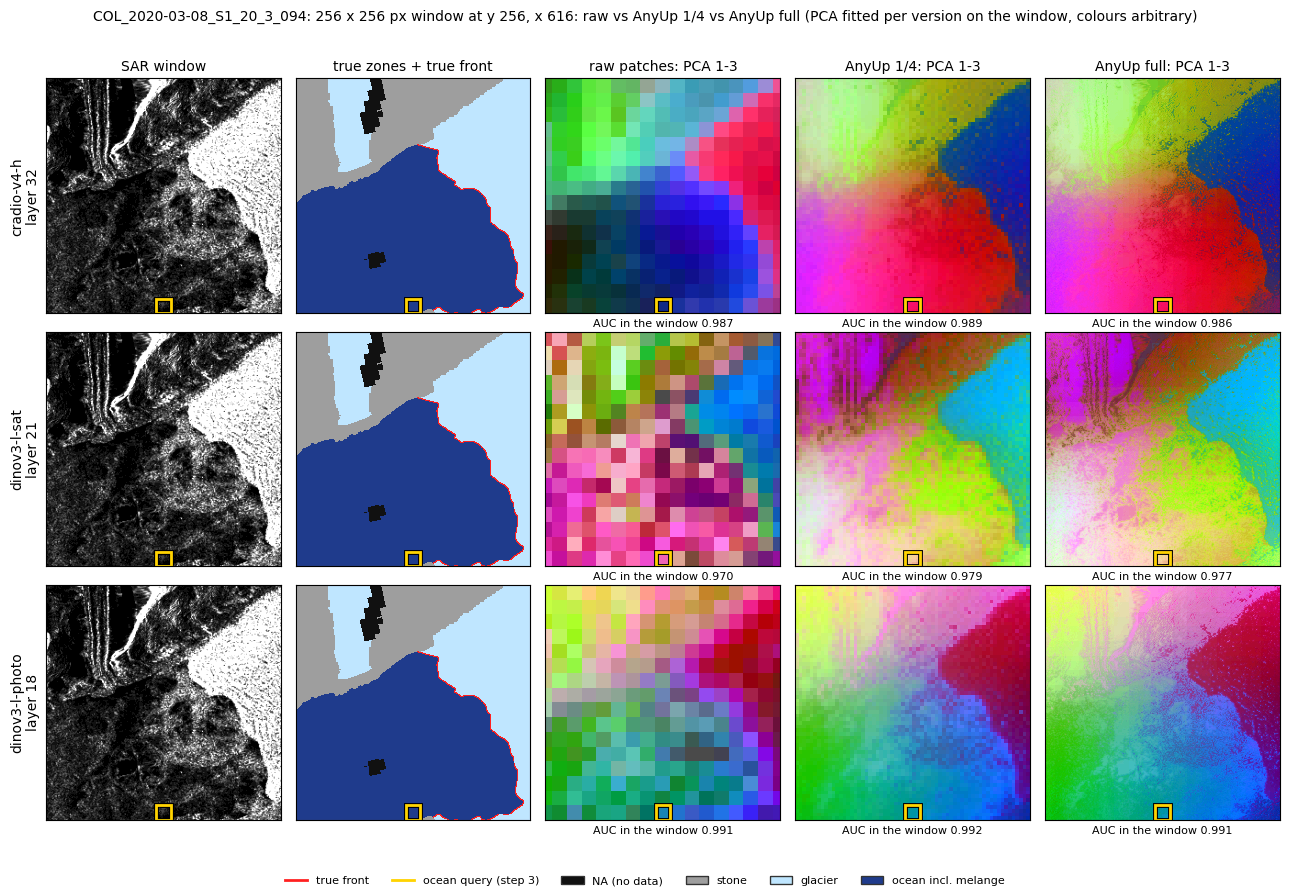

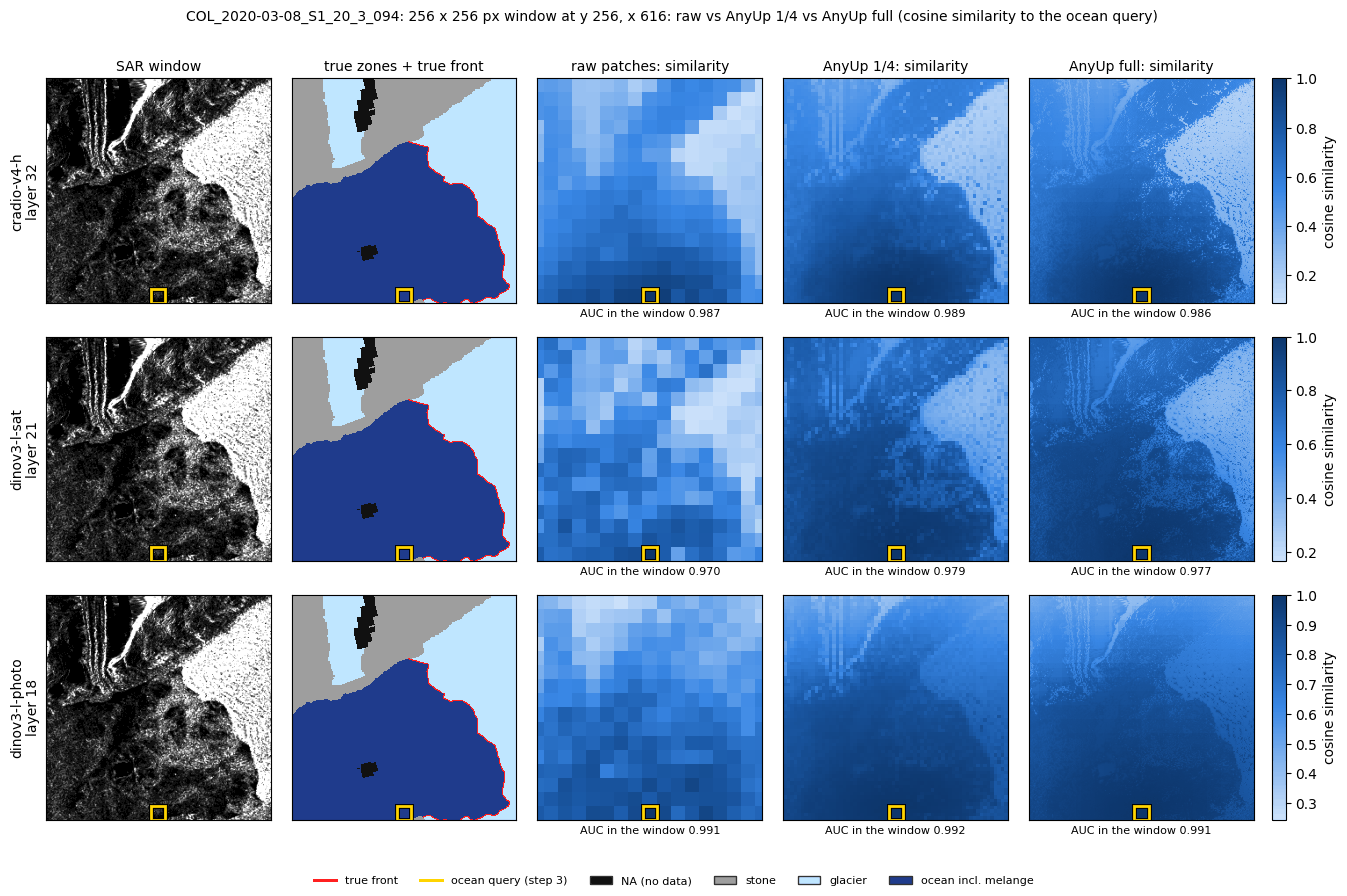

Mapple_2017-09-08_S1_20_2_009: window y 8-263, x 120-375 (256 x 256 px) around the ocean query (row 8, col 15), in the tile at (y 0, x 0) | 20,557 glacier, 26,305 ocean pixels
  cradio-v4-h layer 32: AUC ocean vs glacier in the window: raw patches 0.995 | AnyUp 1/4 0.995 | AnyUp full 0.995
  dinov3-l-sat layer 21: AUC ocean vs glacier in the window: raw patches 0.991 | AnyUp 1/4 0.997 | AnyUp full 0.997
  dinov3-l-photo layer 18: AUC ocean vs glacier in the window: raw patches 0.967 | AnyUp 1/4 0.967 | AnyUp full 0.967
saved /content/drive/MyDrive/sar-transfer/embeddings/zoom_front_Mapple_2017-09-08_S1_20_2_009.png
saved /content/drive/MyDrive/sar-transfer/embeddings/zoom_front_similarity_Mapple_2017-09-08_S1_20_2_009.png


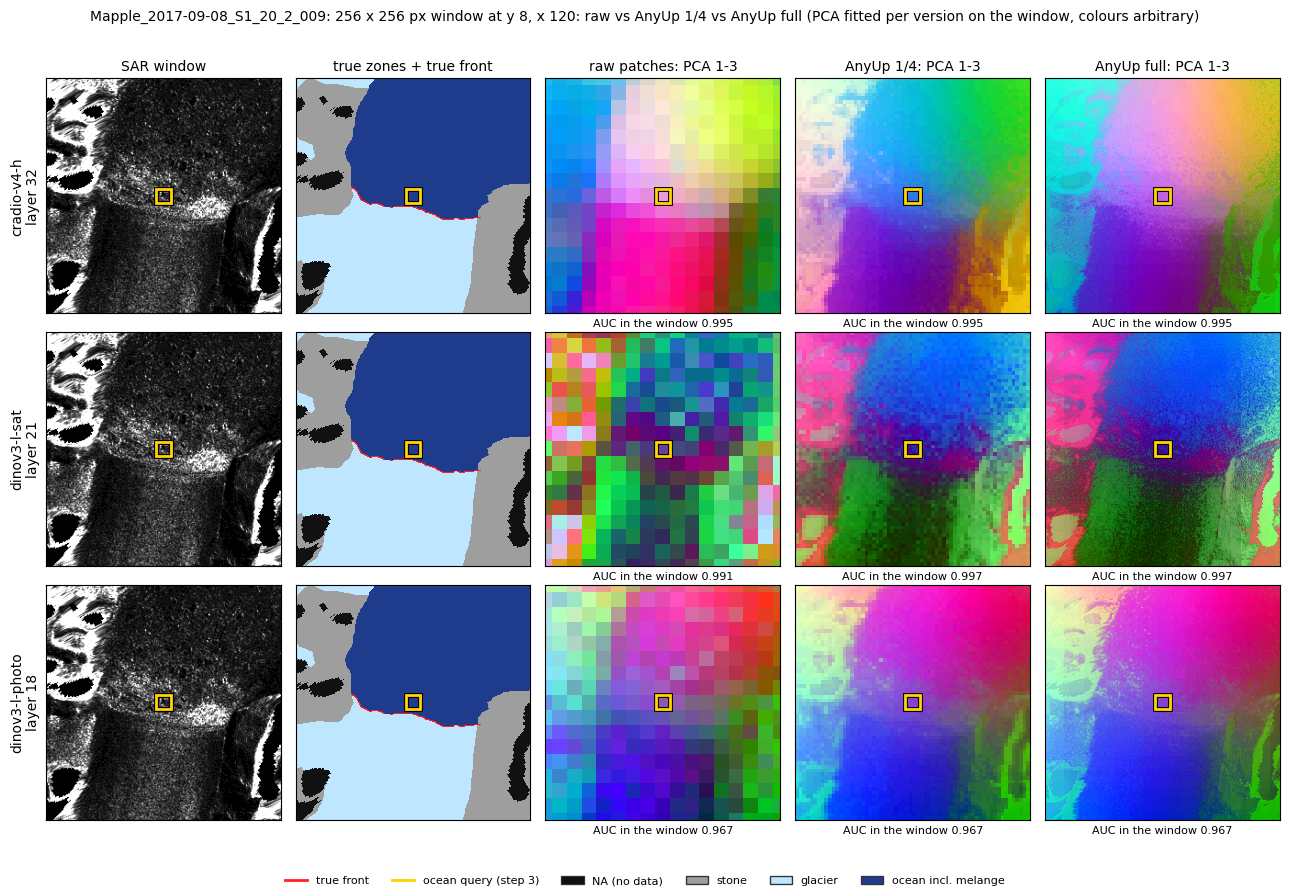

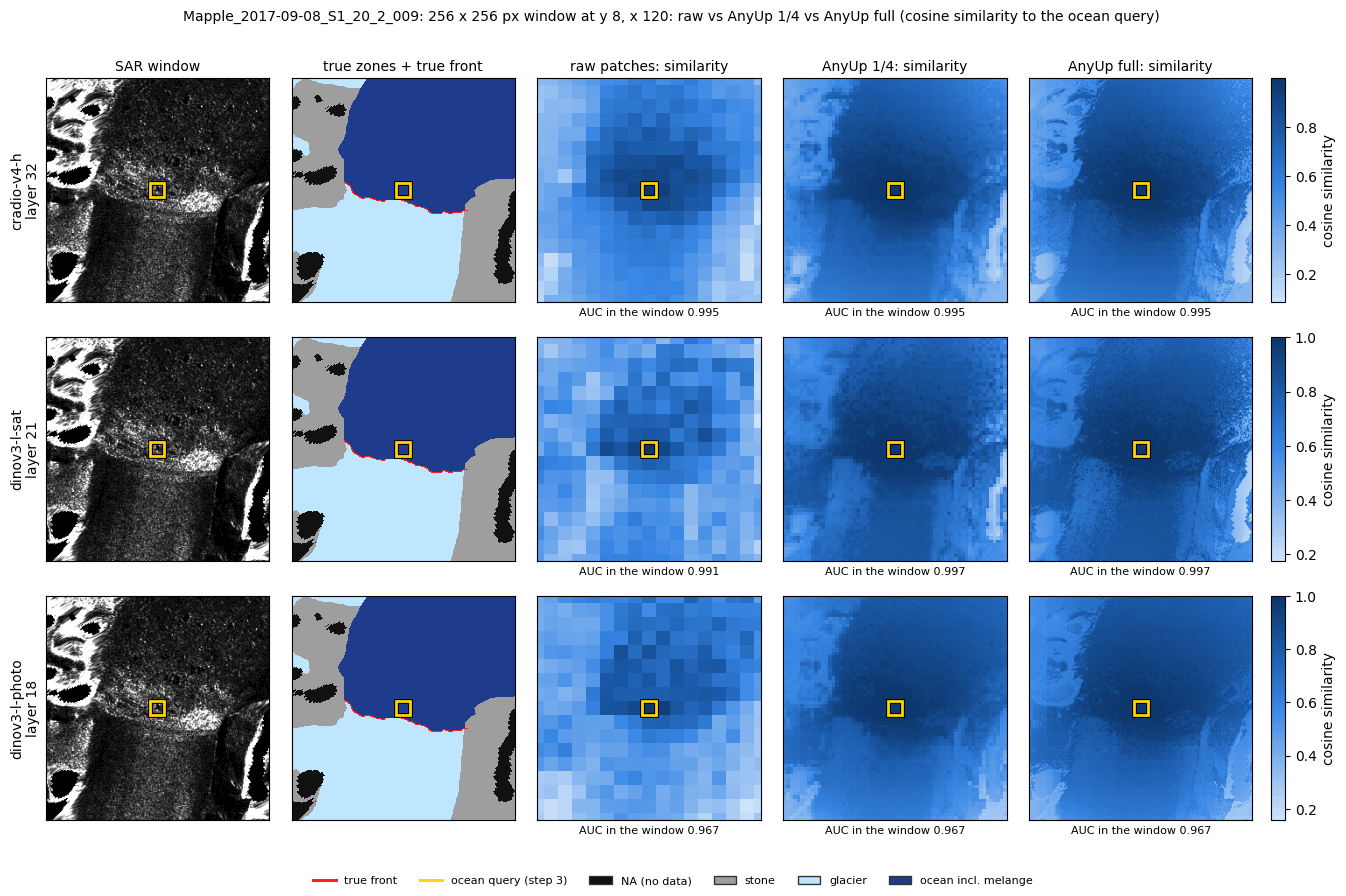

step 6: 1.3 min


In [9]:
# --- cell: STEP 6 -- zoom on the front: raw vs AnyUp 1/4 vs AnyUp full (option B) ---
from sartransfer.embeddings import plot_zoom

t = time.perf_counter()
crop_records = []
for stem, e in emb.items():
    _, _, recs = plot_zoom(e, OUT)
    crop_records += recs
    plt.show()
print(f"step 6: {(time.perf_counter() - t) / 60:.1f} min")

## Step 7: the numbers, saved

One row per image, encoder, query and feature version; the column `features` says which:
- `raw`: steps 3 and 4. Where the query patch is (patch row and column; times 16 for pixels),
  how far it is from the front, its pixel shares (`query_px_share_*`), whether the fallback was
  needed (`query_fallback`) and the rule (`query_rule`); the size of the query's class
  (`n_query_class`), the class shares of its top 100 (`top_k`, `share_*`) and of its top k20
  (`k20`, `k20_share_*`, the like-for-like numbers between images); the AUC of step 4, and the
  number of patches of each class in the whole image.
- `anyup_quarter`: the same for step 5, same query patch. Here `top_k`, `k20` and the counts
  `n_*` are in 4 px blocks (16 blocks = 1 patch); `n_query_class` stays in patches.
- `anyup_full_crop`: step 6, one row per image and encoder (ocean query): the window
  (`crop_y0`, `crop_x0`, `crop_height`, `crop_width`, in px), its glacier and ocean pixels
  (`crop_n_glacier_px`, `crop_n_ocean_px`) and the three window AUCs (`crop_auc_raw`,
  `crop_auc_anyup_quarter`, `crop_auc_anyup_full`). The share and whole-image columns are empty
  in these rows, and the `crop_*` columns are empty in the other rows.

Saved as `embeddings_numbers.csv` next to the figures.

In [10]:
# --- cell: STEP 7 -- the numbers table to Drive ---
import pandas as pd
from sartransfer.embeddings import numbers_table

tab = numbers_table(sim_records, margin_records, anyup_sim_records, anyup_margin_records, crop_records)
tab.to_csv(OUT / "embeddings_numbers.csv", index=False)
pd.set_option("display.width", 250)
print(tab.round(3).to_string(index=False))
print(f"\nsaved {OUT / 'embeddings_numbers.csv'} ({len(tab)} rows)")

                         stem        encoder  layer        features   query  query_row  query_col  query_front_dist_patches  query_px_share_na  query_px_share_stone  query_px_share_glacier  query_px_share_ocean  query_fallback                                                                                                                               query_rule  n_query_class  top_k  share_na  share_stone  share_glacier  share_ocean  k20  k20_share_na  k20_share_stone  k20_share_glacier  k20_share_ocean  auc_ocean_vs_glacier  n_patches  n_na  n_stone  n_glacier  n_ocean  crop_y0  crop_x0  crop_height  crop_width  crop_n_glacier_px  crop_n_ocean_px  crop_auc_raw  crop_auc_anyup_quarter  crop_auc_anyup_full
   COL_2020-03-08_S1_20_3_094    cradio-v4-h     32             raw   ocean         31         46                       1.0                0.0                 0.008                     0.0                 0.992           False   the purest (>= 90 %) ocean patch closest to the true fro

## Step 8: arrays for a GIF, made later on the PC

The maps drawn above, saved small (colours as uint8, similarities as float16, no features), one
file per image: `embeddings_gif_<stem>.npz`. A script on the PC can make an explained GIF from
them, with no GPU. Per encoder: the PCA colour maps (raw patches, AnyUp 1/4 blocks, and the
three versions of the step-6 window), the k-means maps (raw and AnyUp 1/4), the similarity maps
for both queries (raw and AnyUp 1/4) and for the ocean query in the window (three versions);
plus the query places, the window, the patch and block sizes, the encoders and the layers. The
full key list is in the docstring of `save_gif_arrays`. The maps are made again with the same
functions and seeds as the figures, so they are the same maps. The file size is printed.

In [11]:
# --- cell: STEP 8 -- arrays for the GIF (made later on the PC), total time ---
from sartransfer.embeddings import save_gif_arrays

t = time.perf_counter()
for stem, e in emb.items():
    save_gif_arrays(e, OUT)
print(f"step 8: {(time.perf_counter() - t) / 60:.1f} min | files in {OUT.name}/: {sorted(p.name for p in OUT.iterdir())}")
print(f"total time: {(time.perf_counter() - T0) / 60:.1f} min")

saved /content/drive/MyDrive/sar-transfer/embeddings/embeddings_gif_COL_2020-03-08_S1_20_3_094.npz (2.16 MB, 53 arrays)
saved /content/drive/MyDrive/sar-transfer/embeddings/embeddings_gif_Mapple_2017-09-08_S1_20_2_009.npz (1.07 MB, 53 arrays)
step 8: 1.6 min | files in embeddings/: ['class_margins_COL_2020-03-08_S1_20_3_094.png', 'class_margins_Mapple_2017-09-08_S1_20_2_009.png', 'class_margins_anyup_COL_2020-03-08_S1_20_3_094.png', 'class_margins_anyup_Mapple_2017-09-08_S1_20_2_009.png', 'embedding_maps_COL_2020-03-08_S1_20_3_094.png', 'embedding_maps_Mapple_2017-09-08_S1_20_2_009.png', 'embedding_maps_anyup_COL_2020-03-08_S1_20_3_094.png', 'embedding_maps_anyup_Mapple_2017-09-08_S1_20_2_009.png', 'embeddings_gif_COL_2020-03-08_S1_20_3_094.npz', 'embeddings_gif_Mapple_2017-09-08_S1_20_2_009.npz', 'embeddings_numbers.csv', 'similarity_glacier_query_COL_2020-03-08_S1_20_3_094.png', 'similarity_glacier_query_Mapple_2017-09-08_S1_20_2_009.png', 'similarity_glacier_query_anyup_COL_2020-03-